In [77]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle # Usado para escolher cores na curva ROC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize # label_binarize adicionado para ROC
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc # roc_curve e auc adicionados

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [78]:
# ==========================================
# 2. CARREGAMENTO DO DATASET
# ==========================================
print("\nCarregando os dados...")
df = pd.read_csv('BEED_Data.csv')

# Visualizar a distribuição das classes para confirmar o balanceamento original
print("Distribuição original das classes:")
print(df['y'].value_counts())

# Separar features (X) e rótulos (y)
# X1 a X16 são as características do EEG
X = df.drop('y', axis=1).values
y = df['y'].values


Carregando os dados...
Distribuição original das classes:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [79]:
# ==========================================
# 3. PRÉ-PROCESSAMENTO DOS DADOS
# ==========================================
# 3.1 Particionamento Estratificado (Garante o Balanceamento)
# Divisão: 70% Treino, 15% Validação, 15% Teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp
)

# 3.2 Padronização (Z-score normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 3.3 Conversão para Tensores do PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# 3.4 Criação dos DataLoaders (Batching)
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

In [80]:
# ==========================================
# 4. DEFINIÇÃO DA ARQUITETURA DO MODELO
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Evitar Overfitting
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
            # Sem camada Softmax aqui pois utilizaremos a função CrossEntropyLoss 
            # que já combina LogSoftmax + NLLLoss internamente.
        )

    def forward(self, x):
        return self.network(x)

# Instanciando o modelo (16 features de entrada, 4 classes de saída)
input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
model = MLP(input_size=input_dim, num_classes=num_classes).to(device)

In [81]:
# ==========================================
# 5. TREINAMENTO DO MODELO
# ==========================================
criterion = nn.CrossEntropyLoss() # Lida com multiclasse adequadamente
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
best_val_loss = float('inf')

print("\nIniciando o Treinamento...")
for epoch in range(epochs):
    # --- Fase de Treino ---
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Fase de Validação ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # Checkpoint simples (salva a melhor época)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_checkpoint.pth')
    
    # Imprimir progresso a cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}] - Loss Treino: {train_loss:.4f} - Loss Val: {val_loss:.4f}")


Iniciando o Treinamento...
Época [10/50] - Loss Treino: 0.4775 - Loss Val: 0.4052
Época [20/50] - Loss Treino: 0.3796 - Loss Val: 0.3097
Época [30/50] - Loss Treino: 0.3439 - Loss Val: 0.2729
Época [40/50] - Loss Treino: 0.3151 - Loss Val: 0.2538
Época [50/50] - Loss Treino: 0.2962 - Loss Val: 0.2327



Avaliando o modelo no conjunto de Teste...

F1-Score (Macro) no Teste: 0.9019


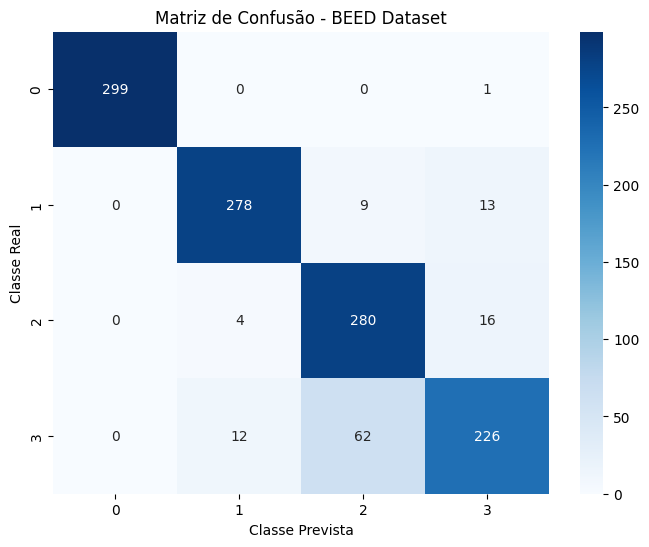

In [82]:
# ==========================================
# 6. AVALIAÇÃO DO MODELO
# ==========================================
print("\nAvaliando o modelo no conjunto de Teste...")
# Carregar o melhor peso validado para evitar overfitting nas épocas finais
model.load_state_dict(torch.load('best_model_checkpoint.pth'))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        # Pega a classe com a maior pontuação
        _, predicted = torch.max(outputs.data, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Métricas selecionadas: F1-Score (Macro) e Matriz de Confusão
f1 = f1_score(y_true, y_pred, average='macro')
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"\nF1-Score (Macro) no Teste: {f1:.4f}")

# Plot da Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - BEED Dataset')
plt.show()

In [83]:
# ==========================================
# 7. SALVAMENTO DO MODELO
# ==========================================
caminho_modelo = 'mlp_beed_final.pth'
torch.save(model.state_dict(), caminho_modelo)
print(f"\nModelo final treinado e salvo com sucesso em: {caminho_modelo}")


Modelo final treinado e salvo com sucesso em: mlp_beed_final.pth
